#Preparar imágenes de Naves Imperiales de Star Wars



In [ ]:
#@title Librerías

import numpy as np
import random
import os
from PIL import Image
from sklearn.model_selection import train_test_split

print("Librerías cargadas.")

Librerías cargadas.


# Cargar imágenes descargadas

In [ ]:
#@title Acceder al Drive

# monta Google Drive:
# Nota: la primera vez se debe confirmar el uso logueandose en "Google Drive File Stream" y obteniendo código de autentificación.
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

# directorio local en Google Drive
path_imagenes = '/content/gdrive/MyDrive/demosColab/demoStarWars/imagenes/ori/'  #@param {type:"string"}


Mounted at /content/gdrive


- Clases cargadas:  12
- Imágenes cargadas:  104
- Ejemplo  Command Ships   (300, 300, 3) : 


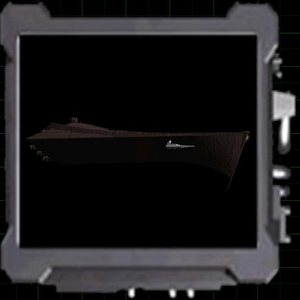

In [ ]:
#@title Cargar imágenes

#@markdown ### Parámetros para imágenes:
imagen_ancho =  300#@param {type:"integer"}
imagen_alto =  300#@param {type:"integer"}
imagen_color = True #@param {type:"boolean"}

# tamaño de las imágenes
if imagen_ancho<=10:
  imagen_alto = 10
if imagen_alto<=10:
  imagen_alto = 10
IMAGE_SHAPE = (imagen_ancho, imagen_alto, (3 if imagen_color else 1))

# carga imagen y prepara como vector
def cargarImagen(imagePathFN):
  global IMAGE_SHAPE
  # abre la imagen
  imag = Image.open(imagePathFN)
  # ajusta Escala Grises/RGB
  if IMAGE_SHAPE[2]==1:
    tipoImage = 'L'
  else:
    tipoImage = 'RGB'
  imag = imag.convert(tipoImage)
  # ajusta tamaño
  imag = imag.resize((IMAGE_SHAPE[0], IMAGE_SHAPE[1]), Image.LANCZOS)
  # transforma a un vector de nros
  arImag = np.array(imag)
  return arImag

# función para cargar las imágenes de árbol de directorios o raiz
def cargarImagenesPath(imagPath, mostrarImg=False, recursive=True, limitarCantDir=None, className=None):
  classes_ori = []
  images_ori = []
  all_els = os.listdir( imagPath )
  all_els.sort()
  for each_el in all_els:
      auxiPath = imagPath + '/' + each_el

      # se fija si es imagen
      if ( each_el.endswith('.png') or each_el.endswith('.jpg') or each_el.endswith('.jpeg') ):
          # carga la imagen
          imag = cargarImagen(auxiPath)
          images_ori.append( imag )
          # determina nombre clase
          if className is None:
            clase =  os.path.splitext(each_el)[0]
          else:
            clase = className
          classes_ori.append( clase )
          # muestra
          if mostrarImg:
            print("\n", clase)
            display( imag )
          # finaliza si llego al máximo limitado
          if (limitarCantDir is not None) and (len(classes_ori) >= limitarCantDir):
              break

      # si es subdirectorio
      elif recursive and os.path.isdir( auxiPath ):
        # procesa subdirectorio recursivo
        auxi_imag, auxi_class = cargarImagenesPath(imagPath=auxiPath,
                                                   mostrarImg=mostrarImg, recursive=recursive,
                                                   limitarCantDir=limitarCantDir,
                                                   className=each_el)
        images_ori.extend(auxi_imag)
        classes_ori.extend(auxi_class)

  return np.array(images_ori), classes_ori

# carga las imagenes
images_ori, classes_ori = cargarImagenesPath(path_imagenes)
print("- Clases cargadas: ", len(np.unique(classes_ori)))
print("- Imágenes cargadas: ", len(classes_ori))

if len(classes_ori)>0:
  print("- Ejemplo ", classes_ori[0], " ", images_ori[0].shape, ": ")
  display( Image.fromarray(images_ori[0] ) )


# inicializa listas
images_train, images_test, classes_train, classes_test = None, None, None, None

#Corregir imágenes descargadas

- Ejemplo  Command Ships   (300, 300, 3) : 


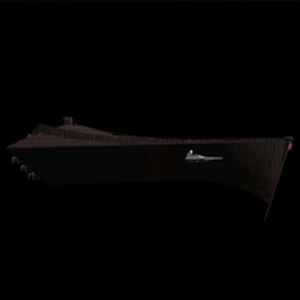

In [ ]:
#@title Eliminar recuadro de las imágenes

#@markdown ### Recorte recuadro
recortar_recuadro = True #@param {type:"boolean"}
sacar_recuadro_superior = 36 #@param {type:"integer"}
sacar_recuadro_izquierdo = 21 #@param {type:"integer"}
sacar_recuadro_derecho = 45 #@param {type:"integer"}
sacar_recuadro_inferior = 55 #@param {type:"integer"}


if recortar_recuadro:
  IMAGE_CROP = (sacar_recuadro_izquierdo, sacar_recuadro_superior, imagen_ancho-sacar_recuadro_derecho, imagen_alto-sacar_recuadro_inferior)

  # recorre todas las imaǵenes descargas y le saca el recuadro
  #new_images_ori = []
  for i in range(len(images_ori)):
    # convierte a image
    new_imag = Image.fromarray(images_ori[i])
    # hace crop
    new_imag = new_imag.crop(IMAGE_CROP)
    # ajusta el tamaño
    new_imag = new_imag.resize((IMAGE_SHAPE[0], IMAGE_SHAPE[1]), Image.LANCZOS)
    # uelve a guardar en lista
    images_ori[i] = np.array(new_imag)


if len(classes_ori)>0:
  print("- Ejemplo ", classes_ori[0], " ", images_ori[0].shape, ": ")
  display( Image.fromarray(images_ori[0]) )




(1)-  Command Ships   (300, 300, 3) : 


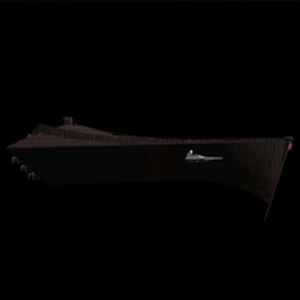


(2)-  Command Ships   (300, 300, 3) : 


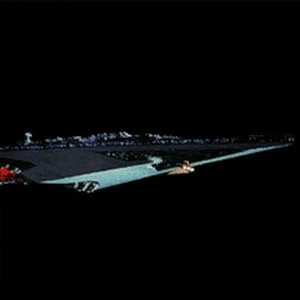


(3)-  Command Ships   (300, 300, 3) : 


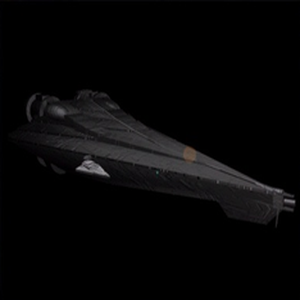


(4)-  Heavy Ships   (300, 300, 3) : 


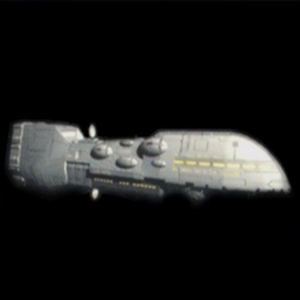


(5)-  Heavy Ships   (300, 300, 3) : 


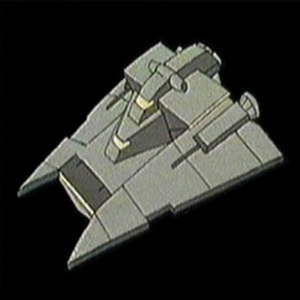


(6)-  Heavy Ships   (300, 300, 3) : 


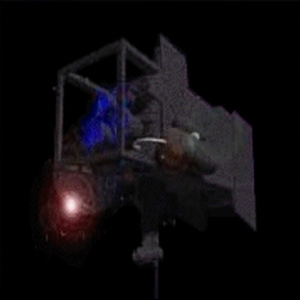


(7)-  Heavy Ships   (300, 300, 3) : 


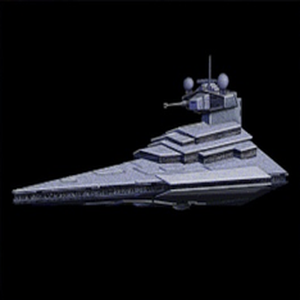


(8)-  Heavy Ships   (300, 300, 3) : 


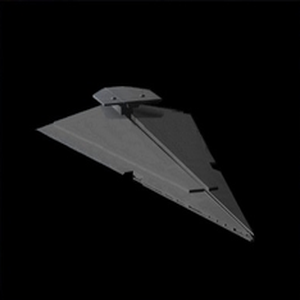


(9)-  Heavy Ships   (300, 300, 3) : 


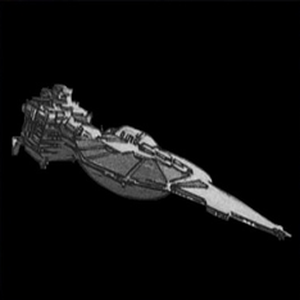


(10)-  Heavy Ships   (300, 300, 3) : 


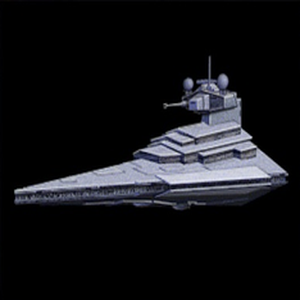


(11)-  Heavy Ships   (300, 300, 3) : 


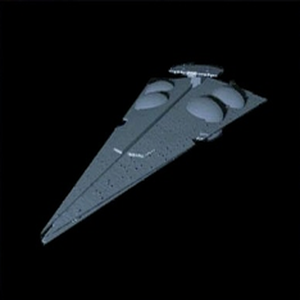


(12)-  Heavy Ships   (300, 300, 3) : 


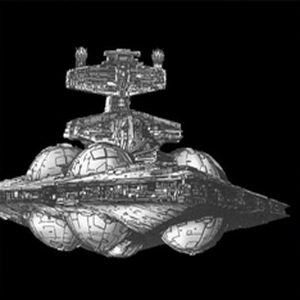


(13)-  Heavy Ships   (300, 300, 3) : 


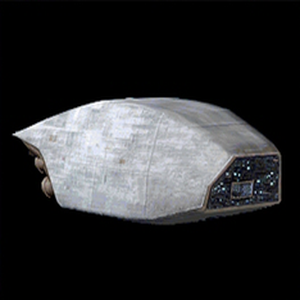


(14)-  Heavy Ships   (300, 300, 3) : 


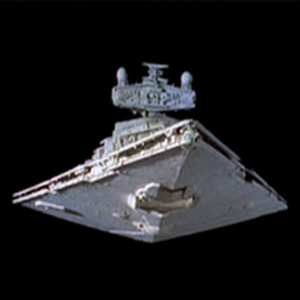


(15)-  Heavy Ships   (300, 300, 3) : 


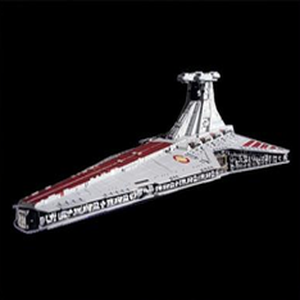


(16)-  Heavy Ships   (300, 300, 3) : 


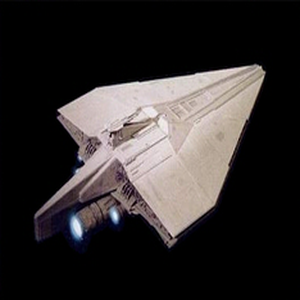


(17)-  Heavy Ships   (300, 300, 3) : 


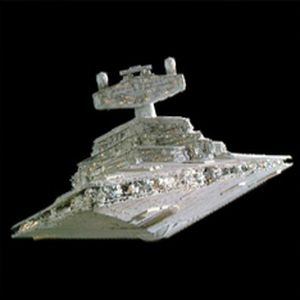


(18)-  Landing Craft   (300, 300, 3) : 


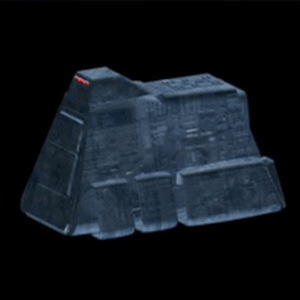


(19)-  Landing Craft   (300, 300, 3) : 


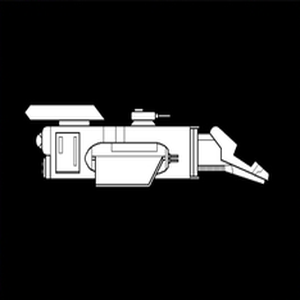


(20)-  Landing Craft   (300, 300, 3) : 


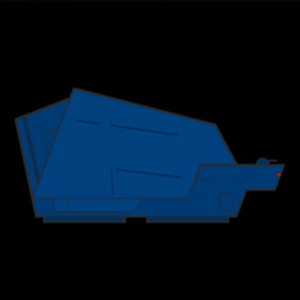


(21)-  Landing Craft   (300, 300, 3) : 


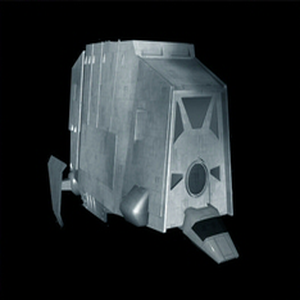


(22)-  Landing Craft   (300, 300, 3) : 


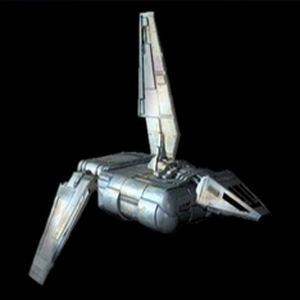


(23)-  Landing Craft   (300, 300, 3) : 


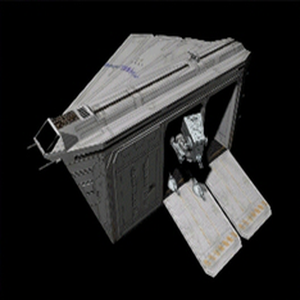


(24)-  Landing Craft   (300, 300, 3) : 


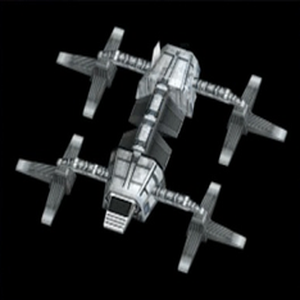


(25)-  Medium Ships   (300, 300, 3) : 


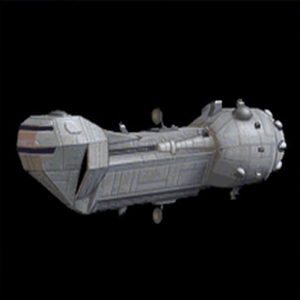

In [ ]:
#@title Revisar imágenes corregidas

revisar_imagenes_cant = 25 #@param{type:"integer"}

for i in range(min(revisar_imagenes_cant, len(classes_ori))):
  print("\n("+str(i+1)+")- ", classes_ori[i], " ", images_ori[i].shape, ": ")
  display( Image.fromarray(images_ori[i]) )



#Aplicar Image Augmentation

Ejemplo de posibles aplicaciones:


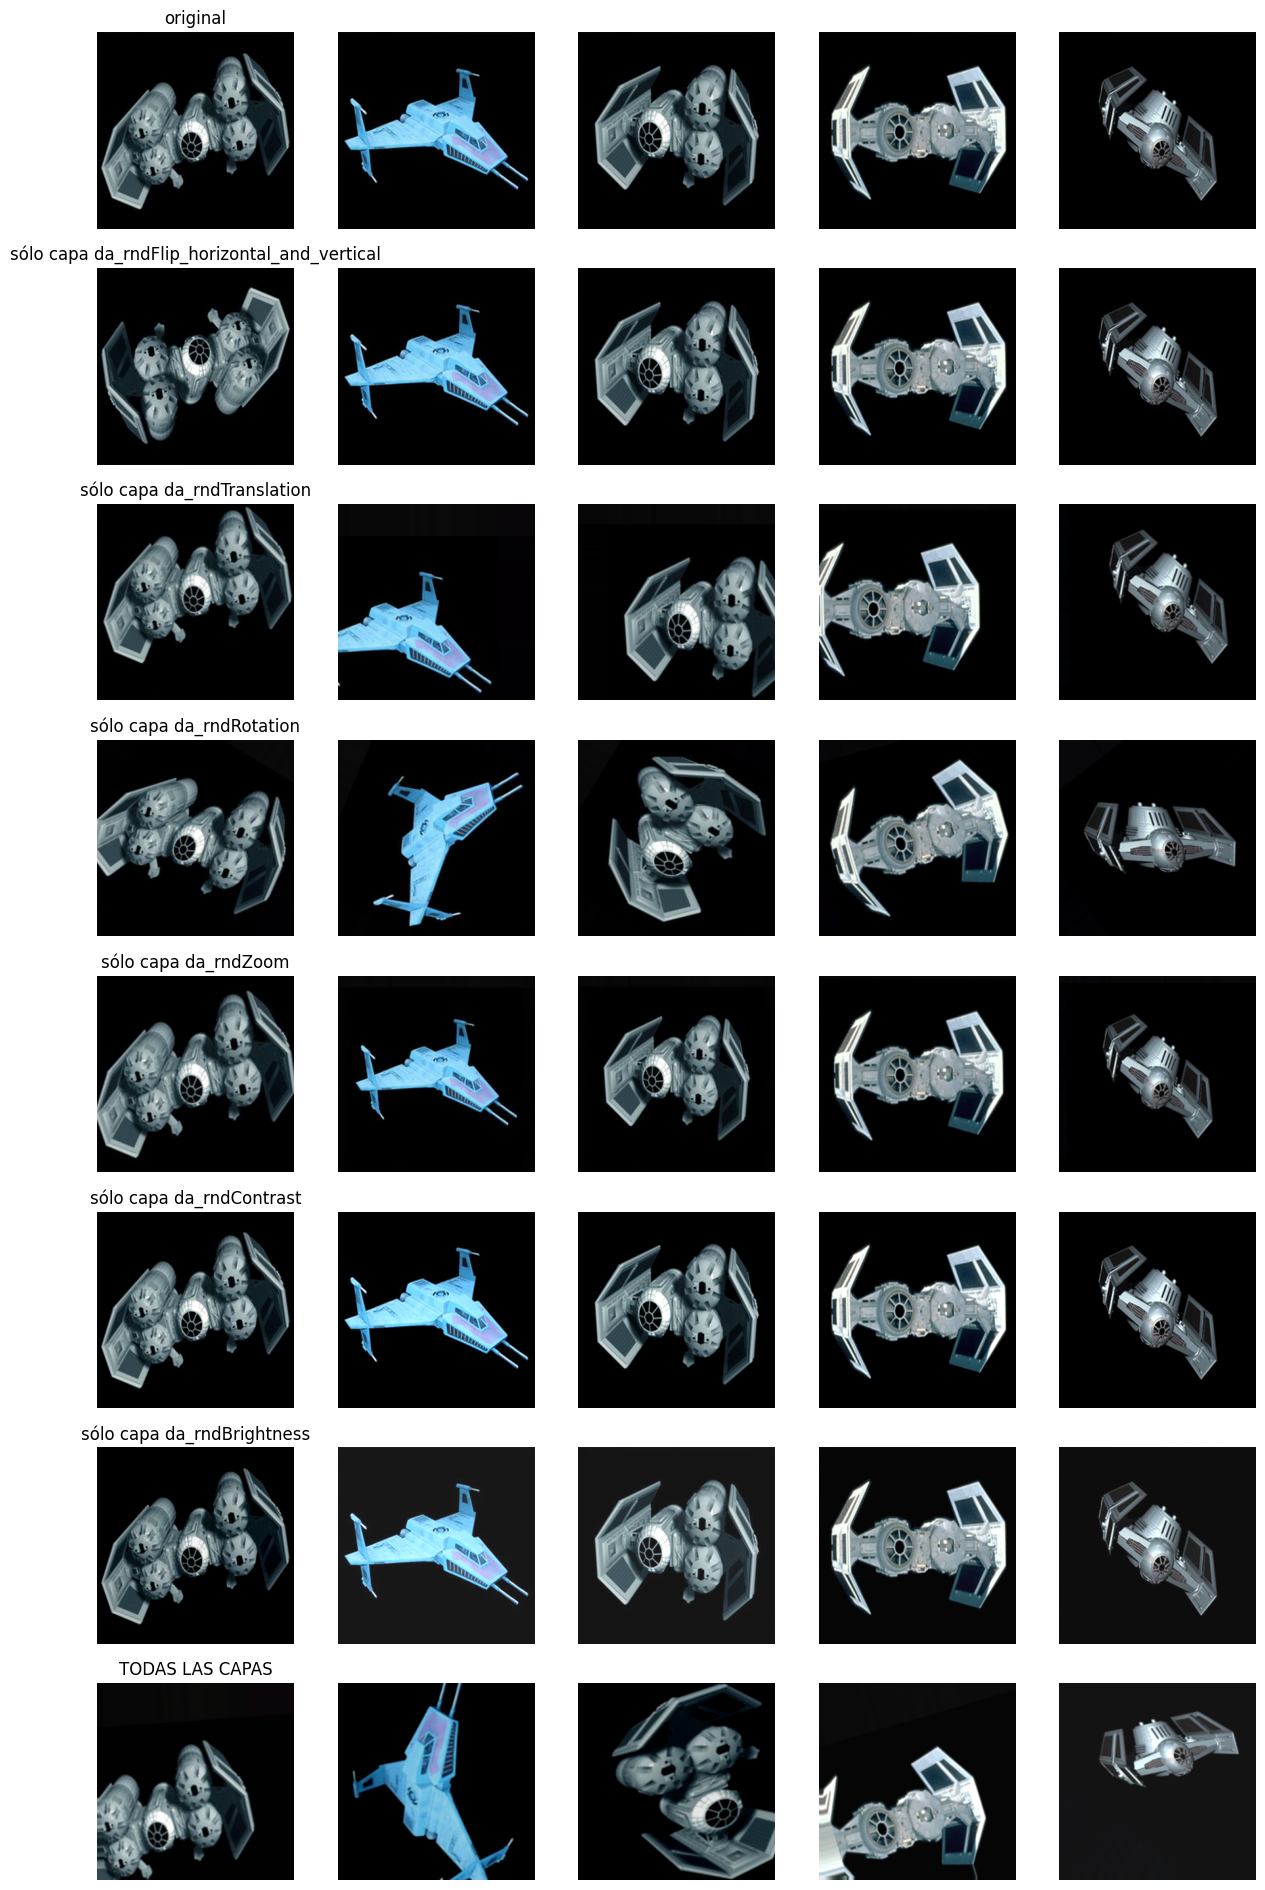

In [ ]:
#@title Definición configuracón para Image Augmentation {"single-column":true}
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt

aplicar_da_preProcesamiento = True #@param {type:"boolean"}

da_preProcesamiento_RandomFlip_Horizontal = True #@param {type:"boolean"}
da_preProcesamiento_RandomFlip_Vertical = True #@param {type:"boolean"}
da_preProcesamiento_RandomTranslation_Horizontal_factor = 0.2 #@param {type:"number"}
da_preProcesamiento_RandomTranslation_Vertical_factor = 0.2 #@param {type:"number"}
da_preProcesamiento_RandomRotation_factor = 0.2 #@param {type:"number"}
da_preProcesamiento_RandomZoom_factor = 0.15 #@param {type:"number"}
da_preProcesamiento_RandomContrast_factor = 0.1 #@param {type:"number"}
da_preProcesamiento_RandomBrightness_factor = 0.1 #@param {type:"number"}

daLayers_modelo = []

# capas de data augmentation (solo para training)
if aplicar_da_preProcesamiento:

  # define seed
  seedValue = 42


  if da_preProcesamiento_RandomFlip_Horizontal or da_preProcesamiento_RandomFlip_Vertical:
      if da_preProcesamiento_RandomFlip_Horizontal:
        modeDAFlip = "horizontal"
        if da_preProcesamiento_RandomFlip_Vertical:
          modeDAFlip = modeDAFlip + "_and_vertical"
      else:
        modeDAFlip = "vertical"
      daLayers_modelo.append( tf.keras.layers.RandomFlip(mode=modeDAFlip, seed=seedValue,
                                                         name="da_rndFlip_"+modeDAFlip) )

  if (da_preProcesamiento_RandomTranslation_Horizontal_factor != 0.0) or (da_preProcesamiento_RandomTranslation_Vertical_factor != 0.0):
    daLayers_modelo.append( tf.keras.layers.RandomTranslation(height_factor=da_preProcesamiento_RandomTranslation_Vertical_factor,
                                                              width_factor=da_preProcesamiento_RandomTranslation_Horizontal_factor,
                                                              seed=seedValue,
                                                              name="da_rndTranslation",
                                                              fill_mode="nearest") )

  if da_preProcesamiento_RandomRotation_factor != 0.0:
      daLayers_modelo.append( tf.keras.layers.RandomRotation(factor=da_preProcesamiento_RandomRotation_factor,
                                                             seed=seedValue,
                                                             name="da_rndRotation",
                                                             fill_mode="nearest") )

  if da_preProcesamiento_RandomZoom_factor != 0.0:
    daLayers_modelo.append( tf.keras.layers.RandomZoom(height_factor=da_preProcesamiento_RandomZoom_factor,
                                                       seed=seedValue,
                                                       name="da_rndZoom",
                                                       fill_mode="nearest") )

  if da_preProcesamiento_RandomContrast_factor != 0.0:
    daLayers_modelo.append( tf.keras.layers.RandomContrast(factor=da_preProcesamiento_RandomContrast_factor,
                                                           seed=seedValue,
                                                           name="da_rndContrast",
                                                           dtype='float32') )

  if da_preProcesamiento_RandomBrightness_factor != 0.0:
    daLayers_modelo.append( tf.keras.layers.RandomBrightness(factor=da_preProcesamiento_RandomBrightness_factor,
                                                             seed=seedValue,
                                                             value_range = [0.0, 1.0],
                                                             name="da_rndBrightness") )



# capas auxiliares para preparar la imagen para DA
prepararImagenDA = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255)
])


# función auxiliar para aplicar todas capas DA en imagen
# nota: al ejecuta la capa de DA se debe training=True para que se aplique la transformación
def aplicarDA(imag):
  global prepararImagenDA, daLayers_modelo
  # prepara la imagen
  prepIm =  prepararImagenDA( imag )
  # aplica todas las capas DA
  for da_lay in daLayers_modelo:
    prepIm = da_lay(prepIm, training=True)
  # desnormaliza los valores de los pixeles
  prepIm = prepIm*255.0
  # devuelve como valores entre 0 y 255
  return prepIm.numpy().astype("uint8")


# Visualize images and augmentations
cantCapasDA = len(daLayers_modelo) + 2
if cantCapasDA <= 2:
  print("No se aplican capas de Image Augmentation.")
else:
  print("Ejemplo de posibles aplicaciones:")
  fig, ax = plt.subplots(cantCapasDA, 5, figsize=(15,cantCapasDA*3))

  j = 0
  for j in range(5):

    # toma al azar las imágenes a mostrar
    posIm = random.randint(1, len(images_ori))
    im = images_ori[posIm-1]

    # muestra imagen original
    ##ax[0][j].imshow((im.astype("uint8")))
    prepIm =  prepararImagenDA( im )
    ax[0][j].imshow( prepIm )

    if j == 0:
      ax[0][j].set_title("original")
    ax[0][j].axis('off')

    # muestra imagen con aplicación capa por capa de DA configurada
    i = 1
    for da_lay in daLayers_modelo:
            ax[i][j].imshow( np.clip( da_lay(prepIm, training=True), 0.0, 1.0) )
            if j == 0:
              ax[i][j].set_title("sólo capa " + da_lay.name)
            ax[i][j].axis('off')
            i = i + 1

    # muestra aplicando todas las capas de DA configurada
    ax[i][j].imshow( aplicarDA(im) )
    if j == 0:
      ax[i][j].set_title("TODAS LAS CAPAS")
    ax[i][j].axis('off')

    j = j + 1

  plt.show()

In [ ]:
#@title Generar imágenes con Image Augmentation

cant_variaciones_generar_da_preProcesamiento = 30 #@param{type:"integer"}
intentar_balancear_clases = True #@param {type:"boolean"}

# inicializa variables
clases_newDA = []
images_newDA = []
cant = 0
cantTotal = 0

if aplicar_da_preProcesamiento and (cant_variaciones_generar_da_preProcesamiento>0):

  # inicializa cantidad por clase
  aux = list(set(classes_ori))
  cantGenerarClases = {}
  clMasImagenes = None
  clMasImagenes_cant = 0
  for cl in aux:
    cantActual = classes_ori.count(cl)
    cantGenerarClases[cl] = [cantActual, cantActual*cant_variaciones_generar_da_preProcesamiento, cant_variaciones_generar_da_preProcesamiento]
    # determina clase con más imágenes
    if (clMasImagenes is None) or (clMasImagenes_cant < cantActual):
      clMasImagenes = cl
      clMasImagenes_cant = cantActual


  # identifica maxima cantidad de imágenes a generar
  cantMaxGenerar = cantGenerarClases[clMasImagenes][0] + cantGenerarClases[clMasImagenes][1]

  print("- Cantidad a generar por clase: ")
  for cl in cantGenerarClases.keys():
    if intentar_balancear_clases:
      # determina cuántas imágenes se generan de la clase para intentar balancearlas
      cantGenerarClases[cl][1] = cantMaxGenerar - cantGenerarClases[cl][0]
      cantGenerarClases[cl][2] = (cantGenerarClases[cl][1]//cantGenerarClases[cl][0]) + 1
    cantTotal += cantGenerarClases[cl][1]
    print("\t " + ("*" if (clMasImagenes == cl) else "") + str(cl) + ": actual " + str(cantGenerarClases[cl][0]) + " + a generar " + str(cantGenerarClases[cl][1]) + " --> " + str(cantGenerarClases[cl][0]+cantGenerarClases[cl][1]) )
  print("")

  print("-- Comenzando a generar ", cantTotal," variaciones de imágenes...")
  for cl, im in zip(classes_ori, images_ori):
    for _ in range(cantGenerarClases[cl][2]):
      if (cantGenerarClases[cl][1]<=0):
        break
      # aplica todas las capas
      imDA = aplicarDA(im)
      # agrega
      clases_newDA.append( cl )
      images_newDA.append( imDA )
      # contabiliza
      cant += 1
      cantGenerarClases[cl][1] -= 1
      if (cant % (cantTotal//20)) == 0:
        print("\t... ya se generaron ", cant, " imágenes...")

  print("\n > Se agregaron " + str(len(clases_newDA)) + " nuevas variaciones de las imágenes recolectadas.")
  print("- Cantidad a generar por clase: ")
  for cl in aux:
    print("\t " + str(cl) + ": " + str(clases_newDA.count(cl)))
  print("")

- Cantidad a generar por clase: 
	 Medium Ships: actual 14 + a generar 606 --> 620
	 TIE Support Craft: actual 10 + a generar 610 --> 620
	 Patrol Craft: actual 5 + a generar 615 --> 620
	 Shuttles: actual 6 + a generar 614 --> 620
	 *TIE Fighters: actual 20 + a generar 600 --> 620
	 Heavy Ships: actual 14 + a generar 606 --> 620
	 Transporters: actual 4 + a generar 616 --> 620
	 Other Starfighters: actual 10 + a generar 610 --> 620
	 TIE Bombers: actual 6 + a generar 614 --> 620
	 TIE Experimental Craft: actual 5 + a generar 615 --> 620
	 Command Ships: actual 3 + a generar 617 --> 620
	 Landing Craft: actual 7 + a generar 613 --> 620

-- Comenzando a generar  7336  variaciones de imágenes...
	... ya se generaron  366  imágenes...
	... ya se generaron  732  imágenes...
	... ya se generaron  1098  imágenes...
	... ya se generaron  1464  imágenes...
	... ya se generaron  1830  imágenes...
	... ya se generaron  2196  imágenes...
	... ya se generaron  2562  imágenes...
	... ya se generaro


(da_4597)-  TIE Bombers   (300, 300, 3) : 


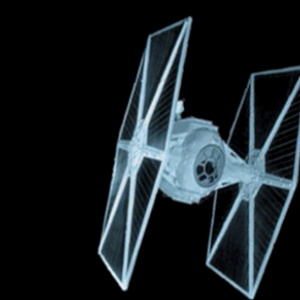


(da_5030)-  TIE Experimental Craft   (300, 300, 3) : 


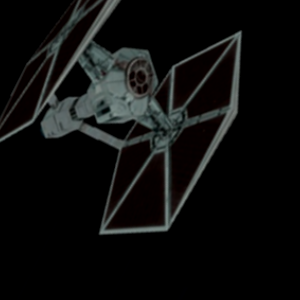


(da_2661)-  Other Starfighters   (300, 300, 3) : 


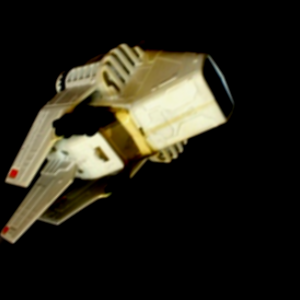


(da_1136)-  Heavy Ships   (300, 300, 3) : 


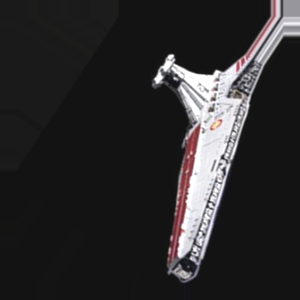


(da_3280)-  Patrol Craft   (300, 300, 3) : 


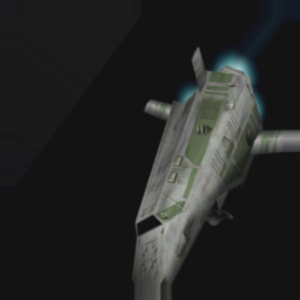


(da_4962)-  TIE Experimental Craft   (300, 300, 3) : 


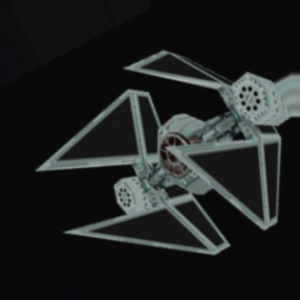


(da_5546)-  TIE Fighters   (300, 300, 3) : 


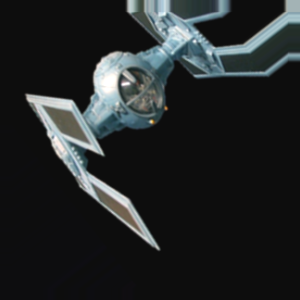


(da_470)-  Command Ships   (300, 300, 3) : 


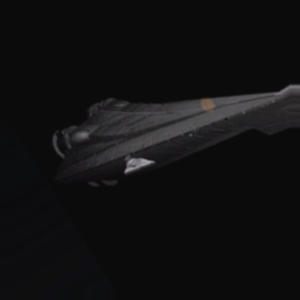


(da_397)-  Command Ships   (300, 300, 3) : 


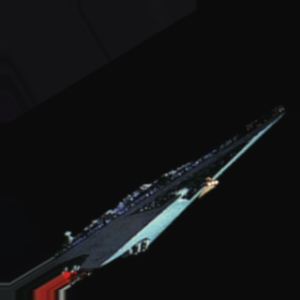


(da_260)-  Command Ships   (300, 300, 3) : 


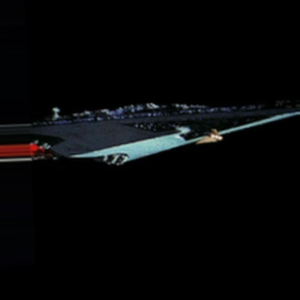


(da_6153)-  TIE Support Craft   (300, 300, 3) : 


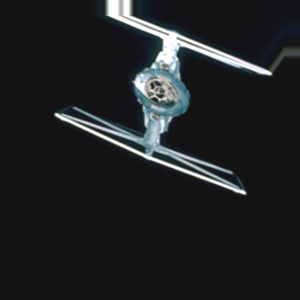


(da_3942)-  Shuttles   (300, 300, 3) : 


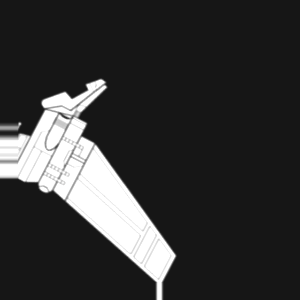


(da_6488)-  TIE Support Craft   (300, 300, 3) : 


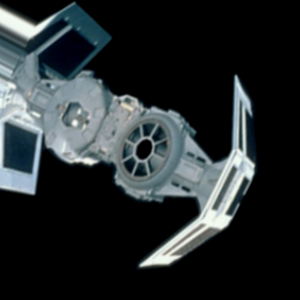


(da_4639)-  TIE Bombers   (300, 300, 3) : 


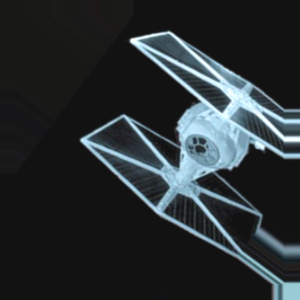


(da_4960)-  TIE Experimental Craft   (300, 300, 3) : 


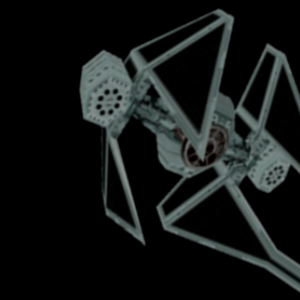


(da_5161)-  TIE Experimental Craft   (300, 300, 3) : 


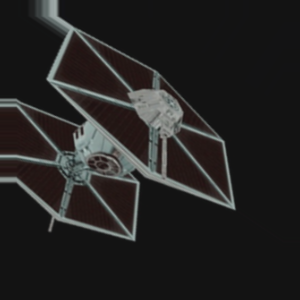


(da_6012)-  TIE Fighters   (300, 300, 3) : 


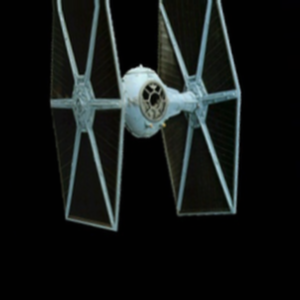


(da_5766)-  TIE Fighters   (300, 300, 3) : 


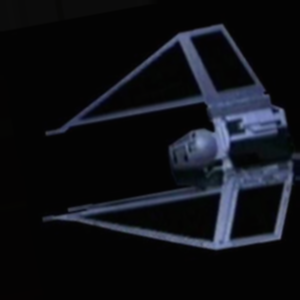


(da_1797)-  Landing Craft   (300, 300, 3) : 


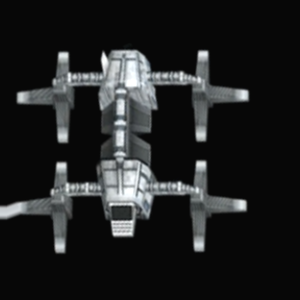


(da_5767)-  TIE Fighters   (300, 300, 3) : 


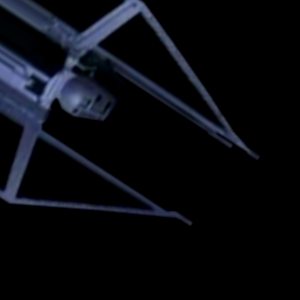


(da_7065)-  Transporters   (300, 300, 3) : 


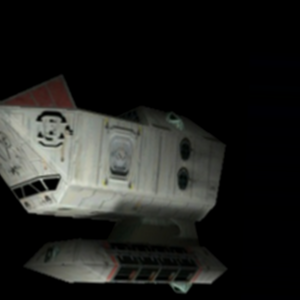


(da_381)-  Command Ships   (300, 300, 3) : 


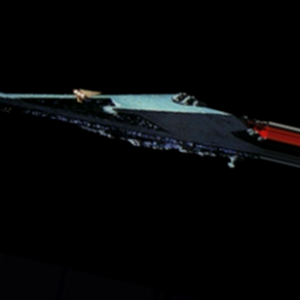


(da_6325)-  TIE Support Craft   (300, 300, 3) : 


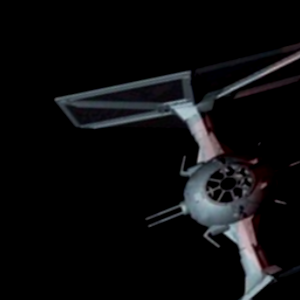


(da_6394)-  TIE Support Craft   (300, 300, 3) : 


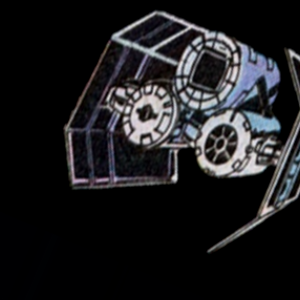


(da_2169)-  Medium Ships   (300, 300, 3) : 


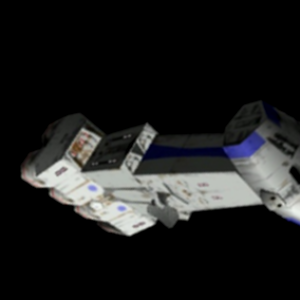


(da_5635)-  TIE Fighters   (300, 300, 3) : 


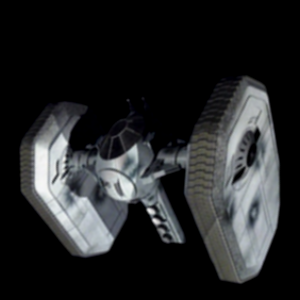


(da_1323)-  Landing Craft   (300, 300, 3) : 


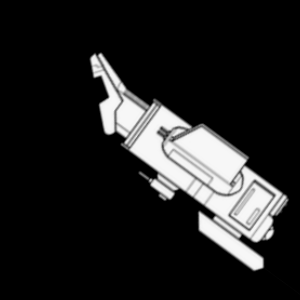


(da_166)-  Command Ships   (300, 300, 3) : 


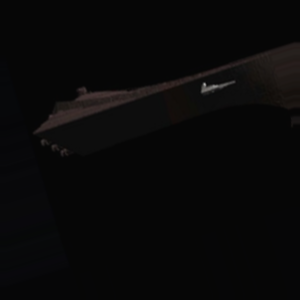


(da_2195)-  Medium Ships   (300, 300, 3) : 


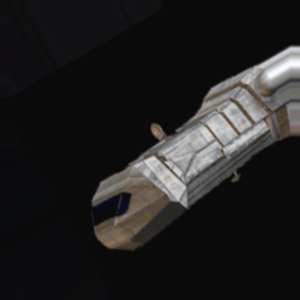


(da_3815)-  Shuttles   (300, 300, 3) : 


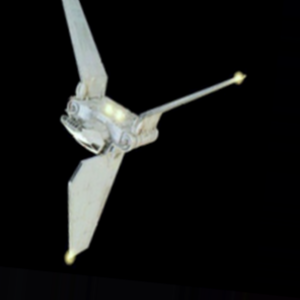


(da_2710)-  Other Starfighters   (300, 300, 3) : 


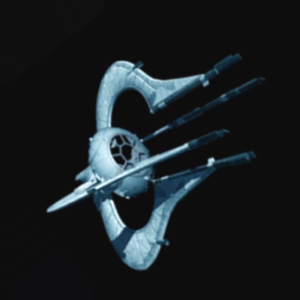


(da_4444)-  TIE Bombers   (300, 300, 3) : 


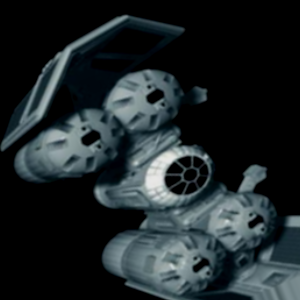


(da_3845)-  Shuttles   (300, 300, 3) : 


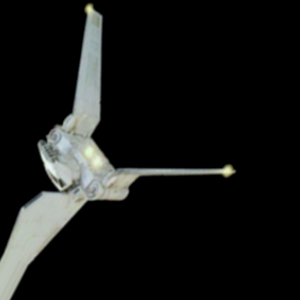


(da_6802)-  Transporters   (300, 300, 3) : 


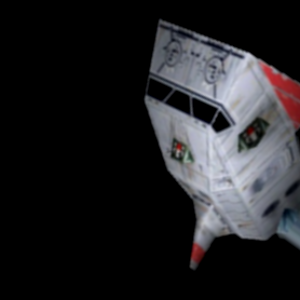


(da_3425)-  Patrol Craft   (300, 300, 3) : 


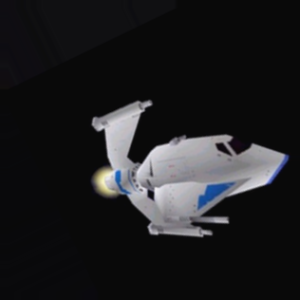


(da_1111)-  Heavy Ships   (300, 300, 3) : 


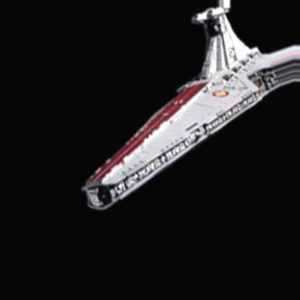


(da_3673)-  Shuttles   (300, 300, 3) : 


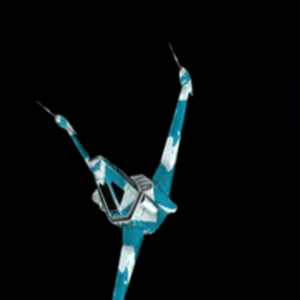


(da_6972)-  Transporters   (300, 300, 3) : 


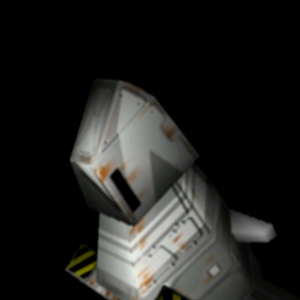


(da_6389)-  TIE Support Craft   (300, 300, 3) : 


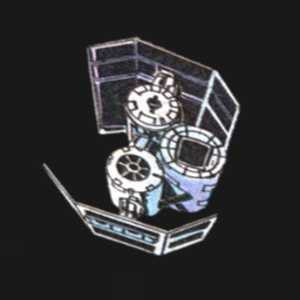


(da_6128)-  TIE Support Craft   (300, 300, 3) : 


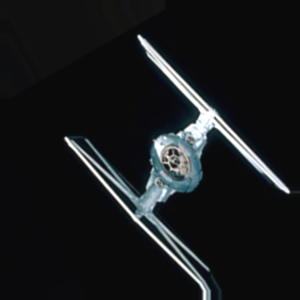


(da_236)-  Command Ships   (300, 300, 3) : 


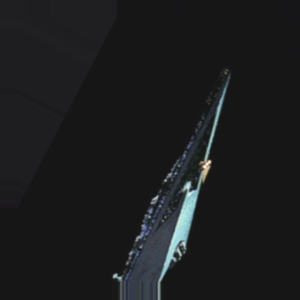


(da_5025)-  TIE Experimental Craft   (300, 300, 3) : 


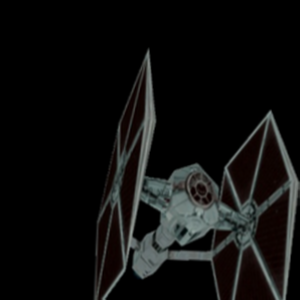


(da_4468)-  TIE Bombers   (300, 300, 3) : 


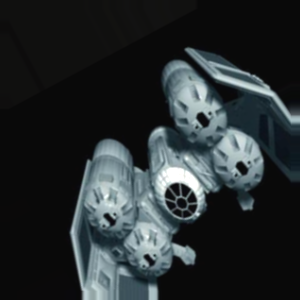


(da_5148)-  TIE Experimental Craft   (300, 300, 3) : 


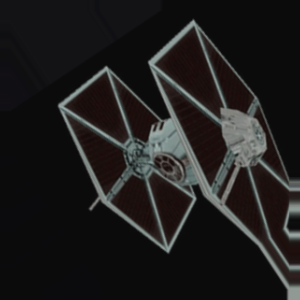


(da_4997)-  TIE Experimental Craft   (300, 300, 3) : 


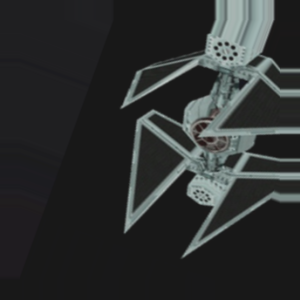


(da_3906)-  Shuttles   (300, 300, 3) : 


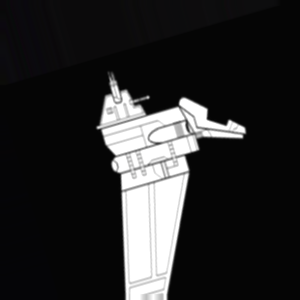


(da_5252)-  TIE Experimental Craft   (300, 300, 3) : 


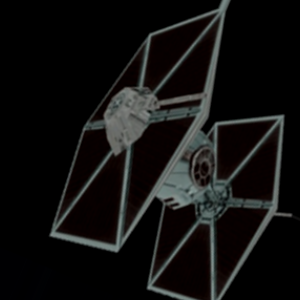


(da_2411)-  Medium Ships   (300, 300, 3) : 


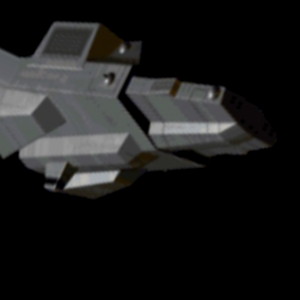


(da_1053)-  Heavy Ships   (300, 300, 3) : 


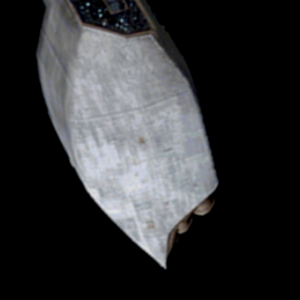


(da_2994)-  Other Starfighters   (300, 300, 3) : 


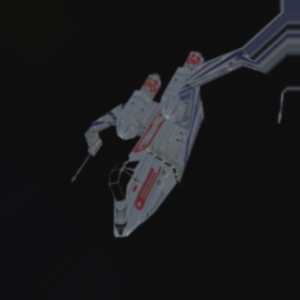

In [ ]:
#@title Revisar imágenes generadas con Image Augmentation (orden al azar)

revisar_imagenes_da_cant = 50 #@param{type:"integer"}

for _ in range(min(revisar_imagenes_da_cant, len(clases_newDA))):
    i = random.randint(1, len(clases_newDA))
    print("\n(da_"+str(i+1)+")- ", clases_newDA[i], " ", images_newDA[i].shape, ": ")
    display( Image.fromarray(images_newDA[i]) )



#Divide en imágenes de Entrenamiento y Prueba

 Total de imágenes disponibles:  7440

> Para Entrenamiento: 
- Clases:  5952
- Imágenes:  5952
- Cantidad por clase: 
	 Medium Ships: 496
	 TIE Support Craft: 496
	 Patrol Craft: 496
	 Shuttles: 496
	 TIE Fighters: 496
	 Heavy Ships: 496
	 Transporters: 496
	 Other Starfighters: 496
	 TIE Bombers: 496
	 TIE Experimental Craft: 496
	 Command Ships: 496
	 Landing Craft: 496

- Ejemplo  Medium Ships   (300, 300, 3) : 


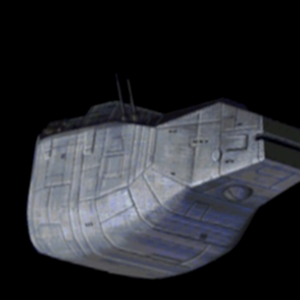



> Para Prueba: 
- Clases:  1488
- Imágenes:  1488
- Cantidad por clase: 
	 Other Starfighters: 124
	 TIE Support Craft: 124
	 Medium Ships: 124
	 Patrol Craft: 124
	 Shuttles: 124
	 TIE Fighters: 124
	 Heavy Ships: 124
	 Transporters: 124
	 Landing Craft: 124
	 TIE Bombers: 124
	 TIE Experimental Craft: 124
	 Command Ships: 124

- Ejemplo  Patrol Craft   (300, 300, 3) : 


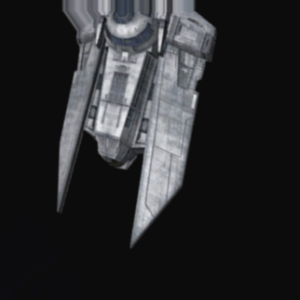

In [ ]:
#@title Divide en imágenes para entrenamiento y para prueba

#@markdown ### Porcentaje de datos para usar en el entrenamiento:
proporcion_porcentaje_datos_entrenamiento =   80#@param {type:"integer"}

# determina la proporción a usar para entrenar y probar
if proporcion_porcentaje_datos_entrenamiento>100:
  propTrain = 1
elif proporcion_porcentaje_datos_entrenamiento<1:
  propTrain = 0.1
else:
  propTrain = proporcion_porcentaje_datos_entrenamiento/100


def mostrar_cant_por_clase(classList):
  aux = list(set(classList))
  print("- Cantidad por clase: ")
  for c in aux:
    print("\t " + str(c) + ": " + str(classList.count(c)))
  print("")


# consolida las nuevas con las recolectadas
clases_dividir = []
clases_dividir.extend(classes_ori)
if clases_newDA is not None:
  clases_dividir.extend(clases_newDA)
images_dividir = []
images_dividir.extend(images_ori)
if images_newDA is not None:
  images_dividir.extend(images_newDA)
print(" Total de imágenes disponibles: ", len(clases_dividir))
print("")

# divide en imaágenes de entrenamiento y prueba
images_train, images_test, classes_train, classes_test = train_test_split(images_dividir, clases_dividir, test_size=(1-propTrain), stratify=clases_dividir)

print("> Para Entrenamiento: ")
print("- Clases: ", len(classes_train))
print("- Imágenes: ", len(classes_train))
mostrar_cant_por_clase(classes_train)

if len(classes_train)>0:
  print("- Ejemplo ", classes_train[0], " ", images_train[0].shape, ": ")
  display( Image.fromarray(images_train[0]) )

# carga las imagenes de prueba
print("\n\n> Para Prueba: ")
print("- Clases: ", len(classes_test))
print("- Imágenes: ", len(images_test))
mostrar_cant_por_clase(classes_test)

if len(classes_test)>0:
  print("- Ejemplo ", classes_test[0], " ", images_test[0].shape, ": ")
  display( Image.fromarray(images_test[0]) )

In [ ]:
#@title Grabar imágenes en Drive

import os
import uuid

# directorio local en Google Drive
exportar_imagenes = True  #@param {type:"boolean"}
path_imagenes = '/content/gdrive/MyDrive/demosColab/demoStarWars/imagenes/'  #@param {type:"string"}

def grabarImagenes(clasesList, imgList, dirPath):
  # crea directorio si no existe
  if not os.path.isdir(dirPath):
    os.mkdir(dirPath)
  # recorre los vectores y graba las imágenes
  cant = 0
  for c, i in zip(clasesList, imgList):
    pathClass = dirPath+c
    if not os.path.isdir(pathClass):
      os.mkdir(pathClass)
    imgFN = pathClass + "/" + str(uuid.uuid4().hex) + ".png"
    img = Image.fromarray(i)
    img.save(imgFN)
    cant += 1
  print("\n> Se grabaron ", cant, "imágenes en ", dirPath)

if exportar_imagenes:
  # fuerza actualización del drive
  drive.flush_and_unmount()
  drive.mount('/content/gdrive')
  if not os.path.isdir(path_imagenes):
    os.mkdir(path_imagenes)
  if (classes_train is not None) and (images_train is not None):
    # graba las imágenes de entrenamiento
    grabarImagenes(classes_train, images_train, path_imagenes+"train/")
  if (classes_test is not None) and (images_test is not None):
    # graba las imágenes de prueba
    grabarImagenes(classes_test, images_test, path_imagenes+"test/")
  print("\nActualizando drive...")
  # fuerza actualización del drive
  drive.flush_and_unmount()
  drive.mount('/content/gdrive')
  print("\nDrive actualizado.")


Mounted at /content/gdrive

> Se grabaron  5952 imágenes en  /content/gdrive/MyDrive/demosColab/demoStarWars/imagenes/train/

> Se grabaron  1488 imágenes en  /content/gdrive/MyDrive/demosColab/demoStarWars/imagenes/test/

Actualizando drive...
Mounted at /content/gdrive

Drive actualizado.
